# 9. The cluster wall-scan

Notebook 8 halved the bond dimension, $\chi=32$ against $\chi=64$, and the wall did not move: it is
gap-limited, not resolution-limited. Two knobs were still untested, the truncation algorithm
(`:rtm` against `:rdm`) and a tighter cutoff. A colleague at BSC ran all three at $\chi=64$ over
$T=2\ldots14$, with an independent SLURM array job per $T$.

The data arrived in two waves. The first was cold-started: every $T$ was computed on its own, with
no warm seed from the previous one. That differs from every local run in this thesis, and it shows.
The entropy dome inflates at $T\approx6$ instead of $T\approx10$, and the naive eigenvalue selector
picks the wrong branch at a couple of times. Sections 1 to 3 analyse that data, section 4 diagnoses
the cause, and section 5 fixes the selector by promoting the phase-based classifier from notebook 5
into `src/transverse_tools.jl`.

One distinction matters when reading the cold data. Eigenvalues and phase rigidity are trustworthy
either way, since an eigenvalue is a Rayleigh quotient and so is quadratically insensitive to the
error in the eigenvector (notebook 8). The entropy dome needs the individual eigenvector, so it is
not comparable to the warm-started local baseline until the rerun lands. Section 6 analyses the warm
$p$-sweep that arrived later and turns the result into a statement about reach against $p$.

In [1]:
# Setup: the shared thesis library and this notebook's constants.
include("../src/thesislib.jl")
using JLD2, Printf, Plots, Statistics
gr()

const P_NNN  = 0.1
const NBETA  = 4

# The three cold-array directories from the first SLURM pipeline.
const COLD_DIRS = Dict(
    "rtm64_full" => "../cluster/archive/rtm_array",
    "rdm64"      => "../cluster/archive/rdm_array",
    "cut_tight"  => "../cluster/archive/cutoff_array",
)

println("thesislib + phase-classification toolkit loaded (classify_tower, tower_gap, ",
        "pick_phys_continuity, block_transfer_eigs_adaptive -- see src/transverse_tools.jl).")

thesislib + phase-classification toolkit loaded (classify_tower, tower_gap, pick_phys_continuity, block_transfer_eigs_adaptive -- see src/transverse_tools.jl).

## Section 1. Merging the cold array results

Each cold-array $T$ point landed as its own file, `cluster/<mode>_array/worker_results_T<T>.jld2`.
This cell merges all three configurations into a single cache,
`results/data/cluster/cold_sweep.jld2`, keyed by `(label, T)` like every other cache in this thesis.
It is idempotent, so it is safe to rerun whenever more points arrive.

In [2]:
# Merge the raw per-T array files into one cache.
mkpath("../results/data/cluster")
cold_cachefile = "../results/data/cluster/cold_sweep.jld2"

cold = Dict{Tuple{String,Float64},Any}()
for (label, dir) in COLD_DIRS
    isdir(dir) || continue
    for filename in readdir(dir)
        regex_match = match(r"worker_results_T([\d.]+)\.jld2", filename)
        regex_match === nothing && continue

        T = parse(Float64, regex_match.captures[1])
        per_T_data = load(joinpath(dir, filename), "done")
        key = (label, T)
        haskey(per_T_data, key) && (cold[key] = per_T_data[key])
    end
end

if isempty(cold)
    cold = load(cold_cachefile, "done")   # raw files not present, fall back to the cache
    println("raw array dirs not found — loaded cache: ", cold_cachefile)
else
    jldsave(cold_cachefile; done=cold)
    println("merged cache: ", cold_cachefile)
end

for label in ["rtm64_full", "rdm64", "cut_tight"]
    println("  ", label, ": ", count(k -> k[1] == label, keys(cold)), " points")
end

merged cache: ../results/data/cluster/cold_sweep.jld2


  rtm64_full: 13 points
  rdm64: 8 points
  cut_tight: 11 points


## Section 2. Is the wall truncation-independent?

This is the main comparison of the notebook. Phase rigidity measures how well defined the individual
eigenvector is, and the cell plots it for the three cold cluster configurations (`:rtm`, `:rdm`, and
the tighter cutoff) together with the two local warm-started series from notebook 8 ($\chi=32$ and
$\chi=64$). If the near-exceptional point comes from the physics, that is from the closing transfer
gap, then all five series should fall on the same geometric decay whatever the bond dimension,
cutoff or truncation algorithm.

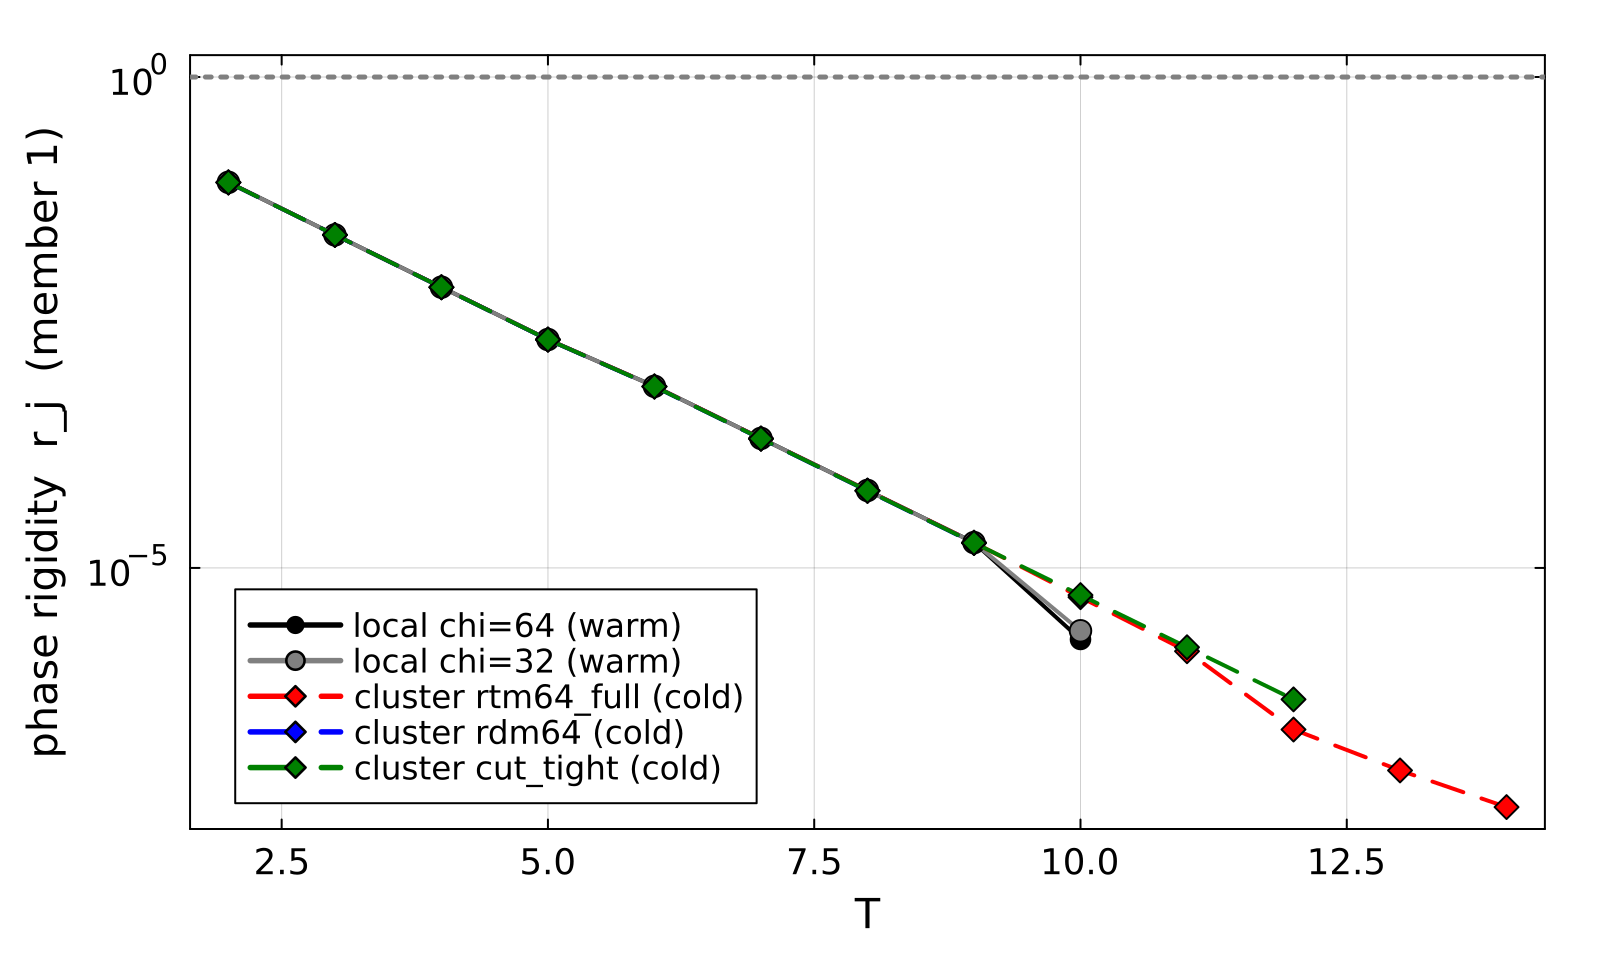

In [3]:
thesis_plot_theme!()   # thesis-quality styling

# Section 2: phase rigidity vs T, five series overlaid.
local_chi64 = load("../results/data/nb13_eigvec_ladder.jld2", "done")
local_chi32_all = load("../results/data/nb13_wallscan.jld2", "done")
local_chi32 = Dict(T => local_chi32_all[("chi32", T)] for (lbl, T) in keys(local_chi32_all) if lbl == "chi32")

rigidity_plot = plot(
    xlabel="T", ylabel="phase rigidity  r_j  (member 1)", yscale=:log10,
    legend=:bottomleft, framestyle=:box,
)

# local, warm-started series (solid lines, filled markers)
for (label, data, color) in [("local chi=64 (warm)", local_chi64, :black), ("local chi=32 (warm)", local_chi32, :gray)]
    Ts_here = sort(collect(keys(data)))
    rigidity_here = [data[T].rigidity[1] for T in Ts_here]
    plot!(rigidity_plot, Ts_here, rigidity_here, marker=:circle, lw=2, color=color, label=label)
end

# cluster, cold-started series (dashed lines, open markers)
cluster_colors = Dict("rtm64_full" => :red, "rdm64" => :blue, "cut_tight" => :green)
for label in ["rtm64_full", "rdm64", "cut_tight"]
    Ts_here = sort([T for (lbl, T) in keys(cold) if lbl == label && !haskey(cold[(lbl, T)], :error)])
    isempty(Ts_here) && continue
    rigidity_here = [cold[(label, T)].rigidity[1] for T in Ts_here]
    plot!(rigidity_plot, Ts_here, rigidity_here, marker=:diamond, ls=:dash, lw=2,
          color=cluster_colors[label], label="cluster " * label * " (cold)")
end

hline!(rigidity_plot, [1.0], ls=:dot, color=:gray, label="")

mkpath("../results/imgs")
savefig(rigidity_plot, "../results/imgs/nb9_rigidity_universal.png")
rigidity_plot

All five series track the same geometric collapse, which is the headline of this notebook: the
near-exceptional point does not care about bond dimension, cutoff or truncation algorithm. It is a
property of the transfer matrix's closing gap. The last of the three $\varepsilon$ knobs, the
truncation algorithm, is now closed alongside bond dimension in notebook 8, with the same verdict.

## Section 3. RTM against RDM

Two questions, answered separately: whether `:rtm` and `:rdm` agree on the physics, meaning the
eigenvalue and its conditioning, and which of the two is cheaper. The check below re-derives the
physical branch from the stored spectra with `pick_phys_continuity` and `classify_tower`, rather
than the naive rank-based index each worker computed at runtime, so the comparison does not inherit
any selector mistakes.

In [4]:
# Section 3a: eigenvalue agreement across rtm / rdm / cutoff at every shared T.
function reselect(entry, previous_phys)
    theta = entry.theta
    i0 = pick_phys_continuity(theta, previous_phys)
    return theta[i0], i0
end

shared_Ts = sort(collect(intersect(
    Set(T for (lbl, T) in keys(cold) if lbl == "rtm64_full" && !haskey(cold[(lbl, T)], :error)),
    Set(T for (lbl, T) in keys(cold) if lbl == "rdm64" && !haskey(cold[(lbl, T)], :error)),
    Set(T for (lbl, T) in keys(cold) if lbl == "cut_tight" && !haskey(cold[(lbl, T)], :error)),
)))

println("Reselected |theta_phys| (rank-based selector at runtime was NOT trusted here):")
@printf("%-5s  %-12s  %-12s  %-12s\n", "T", "rtm", "rdm", "cutoff")
prev = Dict{String,Any}("rtm64_full" => nothing, "rdm64" => nothing, "cut_tight" => nothing)
for T in shared_Ts
    vals = String[]
    for label in ["rtm64_full", "rdm64", "cut_tight"]
        theta_phys, i0 = reselect(cold[(label, T)], prev[label])
        prev[label] = theta_phys
        push!(vals, @sprintf("%.5f", abs(theta_phys)))
    end
    @printf("%-5.1f  %-12s  %-12s  %-12s\n", T, vals[1], vals[2], vals[3])
end

Reselected |theta_phys| (rank-based selector at runtime was NOT trusted here):


T      rtm           rdm           cutoff      
2.0    1.55695       1.55694       1.55695     


3.0    1.55292       1.55303       1.55294     
4.0    1.55062       1.55064       1.55064     
5.0    1.54893       1.54895       1.54895     
6.0    1.54755       1.54758       1.54757     
7.0    1.54633       1.54637       1.54636     
8.0    1.54523       1.54527       1.54526     
9.0    1.55198       1.54425       1.54424     


In [5]:
# Section 3b: cost comparison - elapsed time and iteration count per T.
@printf("%-5s  %-18s  %-18s  %-18s\n", "T", "rtm (s, iters)", "rdm (s, iters)", "cutoff (s, iters)")
function fmt_cost(label, T)
    haskey(cold, (label, T)) || return "--"
    entry = cold[(label, T)]
    haskey(entry, :error) && return "ERROR"
    return @sprintf("%7.0f  @%-5d", entry.elapsed, entry.niters)
end
all_Ts = sort(unique(T for (lbl, T) in keys(cold)))
for T in all_Ts
    @printf("%-5.1f  %-18s  %-18s  %-18s\n", T, fmt_cost("rtm64_full", T), fmt_cost("rdm64", T), fmt_cost("cut_tight", T))
end

total_time(label) = sum(cold[(label, T)].elapsed for T in all_Ts if haskey(cold, (label, T)) && !haskey(cold[(label, T)], :error))
rtm_total, rdm_total, cutoff_total = total_time("rtm64_full"), total_time("rdm64"), total_time("cut_tight")
println()
@printf("Totals: rtm = %.1fh   rdm = %.1fh   cutoff = %.1fh\n", rtm_total/3600, rdm_total/3600, cutoff_total/3600)

shared9 = [T for T in all_Ts if T <= 9.0]
rtm_9 = sum(cold[("rtm64_full", T)].elapsed for T in shared9)
rdm_9 = sum(cold[("rdm64", T)].elapsed for T in shared9)
@printf("T=2..9 only: rtm = %.1fh, rdm = %.1fh  -> rdm is %.1fx slower than rtm\n",
        rtm_9/3600, rdm_9/3600, rdm_9/rtm_9)

T      rtm (s, iters)      rdm (s, iters)      cutoff (s, iters) 
2.0         46  @15             47  @13             50  @14      


3.0       2133  @460            85  @27            115  @48      
4.0       1468  @636           253  @67            276  @75      
5.0       3651  @491          1026  @125           543  @121     
6.0       2317  @570          2855  @185          1162  @193     
7.0       5052  @979         10514  @280          1868  @277     
8.0       5623  @964         29489  @407          3486  @378     
9.0       6792  @943         74117  @639         15088  @1529    
10.0      7444  @833       --                    16576  @1079    
11.0     15429  @1217      --                    51278  @1440    
12.0     21351  @896       --                    61383  @1554    
13.0     33244  @967       --                  --                
14.0     63414  @1209      --                  --                

Totals: rtm = 46.7h   rdm = 32.9h   cutoff = 42.2h


T=2..9 only: rtm = 7.5h, rdm = 32.9h  -> rdm is 4.4x slower than rtm


The eigenvalues agree to 4-5 digits between `:rtm` and `:rdm` at every $T$, so both algorithms see
the same physics. But `:rdm` is about 4x slower over the shared $T=2\ldots9$ range, and the gap
widens at larger $T$. It often reports `"converged"` where `:rtm` reports `"stuck"`, yet each
iteration costs far more — it truncates every vector independently on its own Hermitian density
matrix, rather than the cheaper joint RTM truncation — so the fewer iterations do not save time.
Its theoretical advantage, staying well conditioned through the near-degeneracy, does not appear in
practice either: section 2 already showed the phase rigidity collapsing at the same rate. There is
no dial here that buys back reach, only a slower way to reach the same wall. Production stays with
RTM.

## Section 4. Why the cold dome breaks four steps early

There are two anomalies in the cold data, and both come from the same cause. Every $T$ in the cold
array was computed by an independent SLURM task with `seedL=nothing`, `seedR=nothing` and no
continuity anchor, so the selector fell back to picking the top two eigenvalues by modulus every
time.

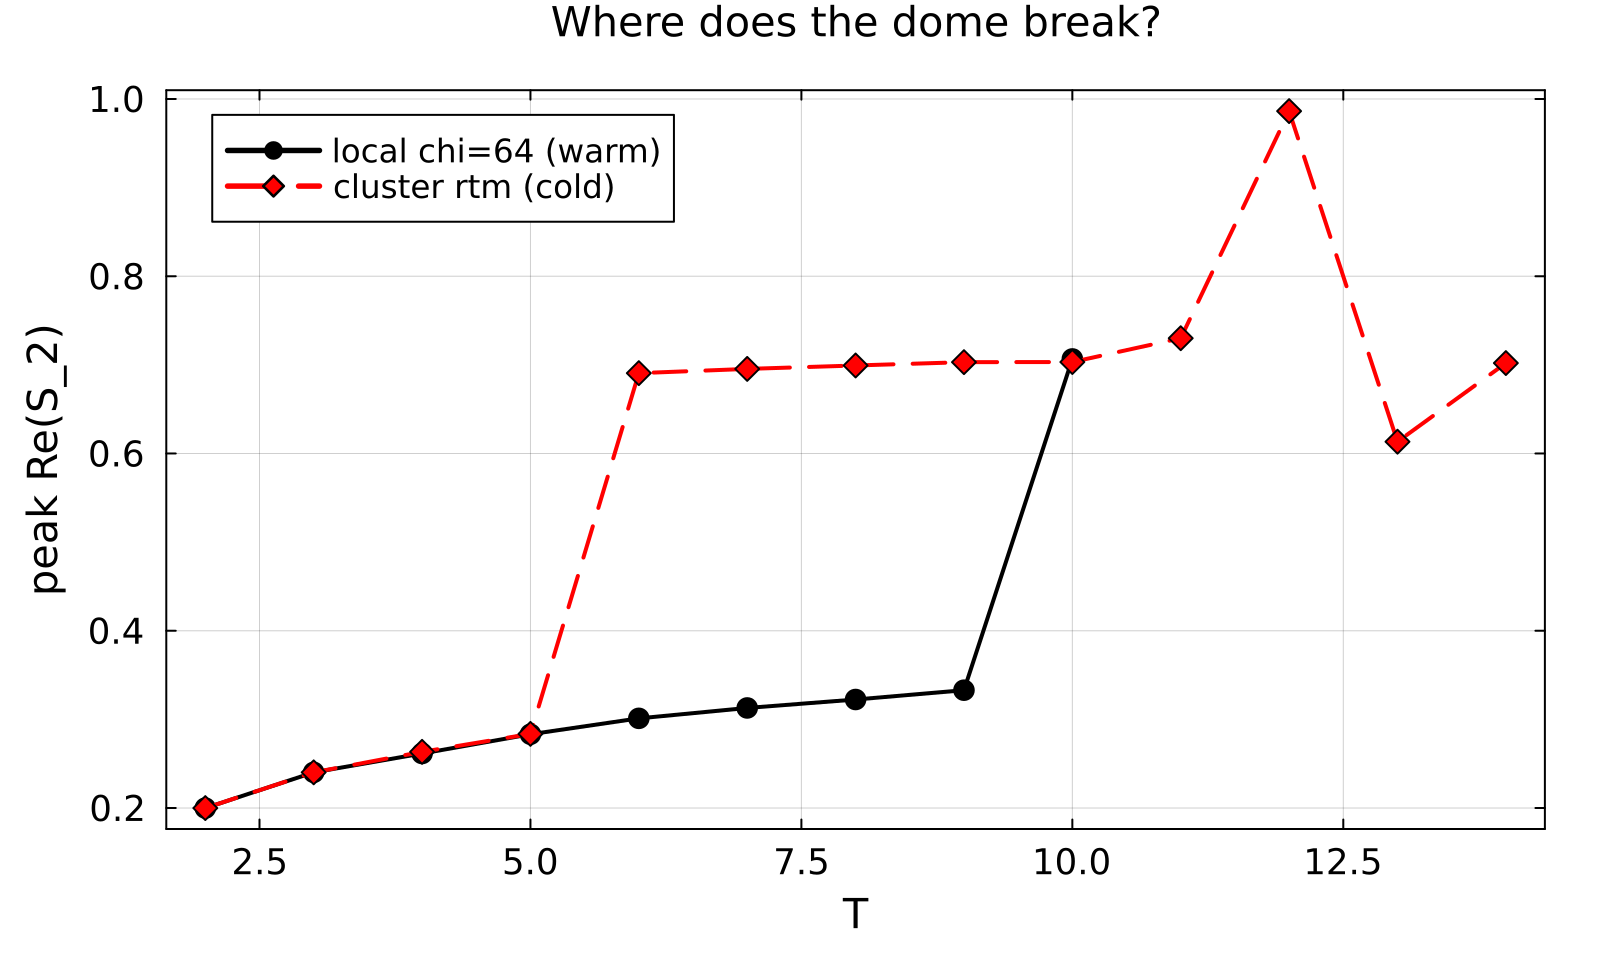

In [6]:
# Section 4a: dome peak vs T, cold cluster (rtm) vs local warm-started chi=64.
dome_plot = plot(xlabel="T", ylabel="peak Re(S_2)", title="Where does the dome break?",
                  legend=:topleft, framestyle=:box)

Ts_local = sort(collect(keys(local_chi64)))
peaks_local = [maximum(real.(local_chi64[T].s2_base)) for T in Ts_local]
plot!(dome_plot, Ts_local, peaks_local, marker=:circle, lw=2, color=:black, label="local chi=64 (warm)")

Ts_cold_rtm = sort([T for (lbl, T) in keys(cold) if lbl == "rtm64_full" && !haskey(cold[(lbl, T)], :error)])
peaks_cold_rtm = [cold[("rtm64_full", T)].peak for T in Ts_cold_rtm]
plot!(dome_plot, Ts_cold_rtm, peaks_cold_rtm, marker=:diamond, ls=:dash, lw=2, color=:red,
      label="cluster rtm (cold)")

dome_plot

The cold dome inflates around $T\approx6$, while the local warm-started baseline stays clean to
$T\approx9$–$10$ at the same phase rigidity, which section 2 already showed is identical between the
two. The difference is not numerical conditioning but which branch the iteration lands on. Near the
near-exceptional point a cold random restart has nothing biasing it toward the physically continuous
eigenvector, whereas a warm-started iteration begins close to the right answer. That matters more
and more as the gap closes and the basin around the physical branch shrinks.

The second anomaly is the wrong-branch selection at $T=12$ and $13$. The cold array's naive selector
always defaulted to the two largest-modulus eigenvalues, which is fine while the physical branch is
the largest one, but breaks down once other members of the cluster grow comparable in size.

In [7]:
# Section 4b: the T=12/13 branch-hop, visible directly in the raw stored spectra.
for T in [11.0, 12.0, 13.0, 14.0]
    haskey(cold, ("rtm64_full", T)) || continue
    entry = cold[("rtm64_full", T)]
    haskey(entry, :error) && continue
    naive_i0 = 1   # the naive selector: top-of-block by modulus, no continuity
    println("T=", T, "  naive |theta_phys|=", round(abs(entry.theta[naive_i0]), digits=4),
            "   full block moduli=", round.(abs.(entry.theta), digits=4))
end

T=11.0

  naive |theta_phys|=1.5532   full block moduli=[1.5532, 1.5464, 1.5436, 1.4036]
T=12.0  naive |theta_phys|=1.7785   full block moduli=[1.7785, 1.631, 1.5526, 1.5478]
T=13.0  naive |theta_phys|=1.9811   full block moduli=[1.9811, 1.5527, 1.5487, 1.5227]
T=14.0  naive |theta_phys|=1.5518   full block moduli=[1.5518, 1.5493, 1.5401, 0.2022]


Warm chaining buys two separate things, and the cold array was missing both.

The first is seeding: handing the iteration the previous $T$'s converged blocks as a starting point.
That is a speed and robustness aid near the wall, and it is lost on any restart unless the blocks
are written to disk. The second is continuity anchoring: remembering the previous $T$'s accepted
eigenvalue, so the selector can pick the closest branch by value instead of guessing by rank. That
is what prevents the $T=12$ and $13$ branch hops seen above.

So the claim that the computation cannot stop and resume was true of the code as it stood, but not
for a fundamental reason: it had never been taught to persist either piece across a restart. The
corrected driver checkpoints the converged $L$/$R$ blocks after every $T$ and reloads them on
startup, so a job that hits its walltime and is resubmitted resumes truly warm.

## Section 5. The selector: dominant modulus, with a continuity guard

The cold branch-hop above needs the right rule for picking the physical $\lambda_0$, and the warm
$p$-sweep of section 6 sharpened what the right rule is. The version now promoted into
`src/transverse_tools.jl` works as follows.

The physical $\lambda_0$ is the dominant eigenvalue of a converged block, the one of largest
$|\theta|$; its $\pm\pi$ partner sits at slightly smaller modulus for the frustration range we can
resolve ($p\lesssim1$). So the selector picks by modulus. Nearest-complex-value continuity was tried
first and rejected: since $\mathrm{Im}(\lambda_0)\approx a\,v\,T$, the phase of the physical
$\lambda_0$ winds by about $a v$ per step in $T$, faster at larger $v$ and so at larger $p$, and a
nearest-value rule drifts onto a stationary partner. Because each rung re-anchors on the previous
one, a single slip then cascades down the whole ladder, which is the $p\ge0.5$ failure of section 6.

Continuity is still useful, but as a guard rather than a selector. `phys_lambda0_suspect` flags any
$T$ whose $|\lambda_0|$ jumps far from the previous trusted rung, which signals a non-convergence
blow-up. The cure for such a point is a warm start, not a cleverer pick.

The cell below re-derives the cold `rtm` ladder with the corrected selector and flags every suspect
point.

In [8]:
# Re-derive the cold rtm64_full ladder with the corrected selector (dominant-modulus) and the
# continuity GUARD (phys_lambda0_suspect): flag every T whose |λ0| jumps from the previous trusted
# rung — the non-convergence blow-ups a cold start produces (here around T≈12/13).
println("Cold rtm64_full ladder — corrected selector (dominant-modulus) + suspect guard:\n")
@printf("%-5s  %-14s  %-10s  %s\n", "T", "|λ0| (dominant)", "tower_gap", "flag")
prev = nothing
for T in sort([T for (lbl,T) in keys(cold) if lbl=="rtm64_full" && !haskey(cold[(lbl,T)],:error)])
    entry  = cold[("rtm64_full", T)]
    theta  = collect(entry.theta)
    i0     = pick_phys_continuity(theta, prev)
    gap    = tower_gap(theta; i0=i0)
    suspect = phys_lambda0_suspect(theta, i0, prev)
    flag   = suspect ? "SUSPECT (|λ0| jump — cold non-convergence)" : "ok"
    @printf("%-5.1f  %-14.4f  %-10s  %s\n", T, abs(theta[i0]), isnan(gap) ? "NaN" : @sprintf("%.4f",gap), flag)
    suspect || (prev = theta[i0])   # only anchor on trustworthy rungs (a flagged one never anchors)
end

Cold rtm64_full ladder — corrected selector (dominant-modulus) + suspect guard:

T      |λ0| (dominant)  tower_gap   flag
2.0    1.5569          0.6513      ok


3.0    1.5529          0.8644      ok
4.0    1.5506          0.9352      ok
5.0    1.5489          0.9648      ok
6.0    1.5476          0.9799      ok
7.0    1.5463          0.9887      ok
8.0    1.5452          0.9942      ok
9.0    1.5520          1.0004      ok
10.0   1.5531          0.7593      ok
11.0   1.5532          NaN         ok
12.0   1.7785          0.9171      ok
13.0   1.9811          0.7817      ok
14.0   1.5493          0.9940      ok


The corrected selector keeps $|\lambda_0|$ flat where the block converged, and the guard isolates the
cold non-convergence points, the branch hop at $T\approx12$–$13$, instead of silently trusting an
inflated $|\lambda_0|$. Both are now `src/`-level tools, so every future driver inherits them. The
real cure for a flagged point is a warm start, which the production driver now does, rather than a
cleverer pick. Section 6 shows the same two tools recovering the warm $p$-sweep, along with the
second finding they forced, the $k$-escalation.

## Section 6. The warm $p$-sweep: how far does the method reach as frustration grows?

The eight-job warm $p$-sweep has landed: seven RTM arms at $p = 0, 0.1, 0.3, 0.5, 0.8, 1.0, 1.5$.
Each arm ran `psweep p 14` — warm-started, checkpointed, $T=2\ldots14$, $\chi=64$ — writing its own
cache. This is the data that turns the barrier into a statement about $p$, and analysing it surfaced
the two fixes now built into the selector of section 5 and into `block_transfer_eigs_adaptive`. The
RDM control that was queued alongside it has since landed too, and is read in section 8.

The first is the selector cascade described above. The old whole-block continuity rule drifted onto
a partner and cascaded: at $p=0.5$ it collapsed $|\lambda_0|$ to $0.16$ at $T=4$ and tracked
partners for every higher $T$. Re-derived with the corrected selector, which is pure post-processing
on the same stored spectra, $p=0.5$ comes out clean, with a flat $|\lambda_0|\approx1.9$ and a
monotone barrier. Nothing had to be recomputed.

The second is that $k$ is too small at large $p$. For $p\gtrsim0.8$ the leading $k=4$ block is
$\lambda_0$ plus $\pi$-partners only, with the real $\lambda_1$ pushed out, so the barrier cannot be
measured at all without a larger block. These arms ran with escalation disabled (`k_retry=4`); the
next run must set `k_retry=8` so the wrapper steps $k\to6\to8$ until a tower member appears.

This section reads the July arms as they were, which is the point: it is the record of the selector
failure and its repair. The $p\ge0.8$ arms and the July $p=0.3$ and $p=0.5$ files now live in
`results/data/cluster/archive/`, since the August round supersedes $p=0.3$ and $p=0.5$ and
$p\ge0.8$ falls outside the thesis range. Section 8 reads the August data.

Below we load the arms, re-derive the physical branch with the corrected selector and guard, and
read the reach directly.

In [9]:
# Load the July RTM arms. The p>=0.8 arms and the superseded p=0.3/0.5 files sit in archive/.
psweep_files = [(0.0, "sweep_rtm_p0.0.jld2"),
                (0.1, "sweep_rtm_p0.1.jld2"),
                (0.3, "archive/sweep_rtm_p0.3_T7_superseded.jld2"),
                (0.5, "archive/sweep_rtm_p0.5_broken.jld2"),
                (0.8, "archive/sweep_rtm_p0.8.jld2"),
                (1.0, "archive/sweep_rtm_p1.0.jld2"),
                (1.5, "archive/sweep_rtm_p1.5.jld2")]
warm = Dict{Float64,Any}()
for (p, fname) in psweep_files
    path = joinpath("../results/data/cluster", fname)
    isfile(path) && (warm[p] = load(path, "done"))
end

# Re-derive each arm with the CORRECTED selector + guard (post-processing on the stored spectra).
# Per (p,T) we classify the physical λ0 into one of four states:
#   :ok      converged, dominant λ0 stable, a tower member λ1 present (barrier measurable)
#   :nok1    converged but NO tower member in the block (tower_gap=NaN) → needs a larger k
#   :suspect |λ0| jumped from the previous trusted rung → non-convergence blow-up
#   :error   the solver's own validity guard rejected it (collapsed/overflow — near-exact degeneracy)
function analyze_arm(p)
    dp    = warm[p]
    label = "rtm_p$p"
    Ts    = sort([k[2] for k in keys(dp)])
    prev  = nothing
    rows  = NamedTuple[]
    for T in Ts
        entry = dp[(label, T)]
        if haskey(entry, :error)
            push!(rows, (T=T, mag=NaN, gap=NaN, status=:error)); continue
        end
        theta = collect(entry.theta)
        i0    = pick_phys_continuity(theta, prev)
        gap   = tower_gap(theta; i0=i0)
        status = phys_lambda0_suspect(theta, i0, prev) ? :suspect : (isnan(gap) ? :nok1 : :ok)
        push!(rows, (T=T, mag=abs(theta[i0]), gap=gap, status=status))
        (status in (:ok, :nok1)) && (prev = theta[i0])   # anchor on any valid |λ0| (nok1 has one too)
    end
    return rows
end

# Physical-branch reach = largest T reachable through a CONTIGUOUS run where the dominant λ0 is
# valid (ok or nok1); it breaks at the first suspect/error. (nok1 = |λ0| fine but gap needs k↑.)
function clean_reach(rows)
    reached = 0.0
    for row in rows
        row.status in (:ok, :nok1) || break
        reached = row.T
    end
    return reached
end

symbol = Dict(:ok=>"·", :nok1=>"k", :suspect=>"!", :error=>"x")
println("Warm p-sweep, corrected selector — status per T (T=2 → 14):\n")
@printf("  %-5s | %-15s | %s\n", "p", "T=2 .......... 14", "clean reach")
for (p,_) in psweep_files
    haskey(warm, p) || continue
    rows = analyze_arm(p)
    line  = join([symbol[r.status] for r in rows], "")
    @printf("  %-5.1f | %-15s | T ≤ %.0f\n", p, line, clean_reach(rows))
end
println("\n  legend:  · ok   k need-k↑(λ1 absent)   ! suspect-jump   x collapse-error")

Warm p-sweep, corrected selector — status per T (T=2 → 14):



  p     | T=2 .......... 14 | clean reach
  0.0   | ···········     | T ≤ 12


  0.1   | ·······         | T ≤ 8
  0.3   | ······          | T ≤ 7
  0.5   | ······          | T ≤ 7
  0.8   | k·!··           | T ≤ 3
  1.0   | ·!x!!x!!x!x!x   | T ≤ 2
  1.5   | xxxxxx·xxxxxx   | T ≤ 0

  legend:  · ok   k need-k↑(λ1 absent)   ! suspect-jump   x collapse-error


In [10]:
# The p=0.5 recovery, side by side: the STORED branch (old cascading selector, baked into the file)
# vs the CORRECTED branch (dominant-modulus), from the SAME stored eigenvalues.
println("p=0.5 recovery — same spectra, corrected selection only (no recompute):\n")
@printf("  %-4s | %-26s | %-24s\n", "T", "STORED (cascaded selector)", "CORRECTED (dominant-mod)")
dp = warm[0.5]; prev = nothing
for T in sort([k[2] for k in keys(dp) if !haskey(dp[k], :error)])
    entry = dp[("rtm_p0.5", T)]
    theta = collect(entry.theta)
    i0    = pick_phys_continuity(theta, prev)
    gap   = tower_gap(theta; i0=i0)
    @printf("  %-4.0f | |λ0|=%.4f  gap=%7.3f     | |λ0|=%.4f  gap=%.4f\n",
            T, abs(entry.theta_phys), entry.tower_gap, abs(theta[i0]), gap)
    prev = theta[i0]
end

p=0.5 recovery — same spectra, corrected selection only (no recompute):

  T    | STORED (cascaded selector) | CORRECTED (dominant-mod)
  2    | |λ0|=1.8954  gap=  0.830     | |λ0|=1.8954  gap=0.8303


  3    | |λ0|=1.6580  gap=  1.151     | |λ0|=1.9086  gap=0.8687
  4    | |λ0|=0.1635  gap= 13.846     | |λ0|=2.2641  gap=0.8329
  5    | |λ0|=1.7841  gap=  0.991     | |λ0|=1.9256  gap=0.9313
  6    | |λ0|=1.6531  gap=  1.143     | |λ0|=1.9081  gap=0.9537
  7    | |λ0|=1.8422  gap=  1.050     | |λ0|=1.9334  gap=0.9528


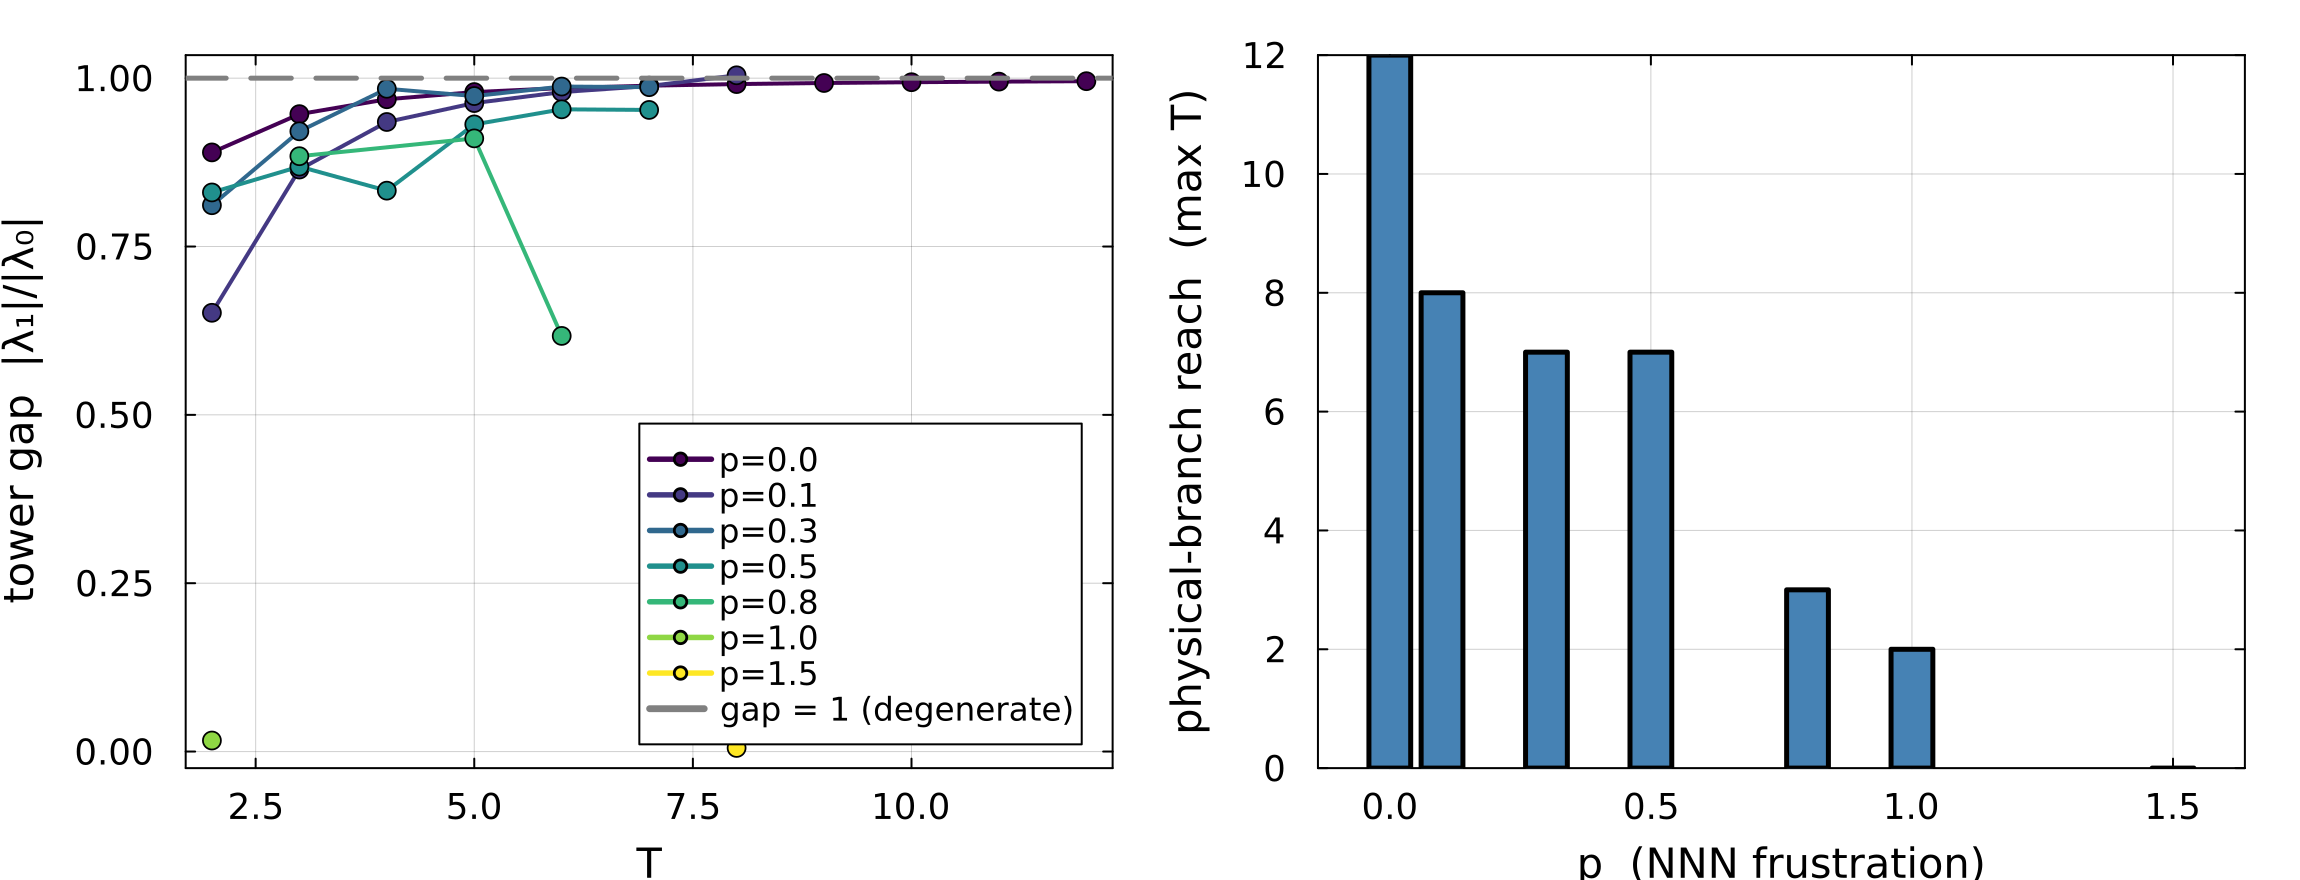

In [11]:
# thesis-quality styling (no in-figure title: the caption does that job)
thesis_plot_theme!()

# Figure 1: the physical tower gap |λ1|/|λ0| vs T, one curve per p (trustworthy :ok points only).
# This is the barrier made p-dependent — it closes toward 1 (degeneracy) and the reach shrinks with p;
# p≳0.8 has essentially no measurable barrier at k=4 (λ1 absent / collapse).
palette = cgrad(:viridis, length(psweep_files), categorical=true)

fig_gap = plot(xlabel="T", ylabel="tower gap  |λ₁|/|λ₀|", framestyle=:box, grid=true,
               legend=:bottomright)
for (idx,(p,_)) in enumerate(psweep_files)
    haskey(warm, p) || continue
    rows = analyze_arm(p)
    ok   = [(r.T, r.gap) for r in rows if r.status == :ok]
    isempty(ok) && continue
    plot!(fig_gap, first.(ok), last.(ok); marker=:circle, ms=5, lw=2, color=palette[idx], label="p=$p")
end
hline!(fig_gap, [1.0]; ls=:dash, color=:gray, label="gap = 1 (degenerate)")

# Figure 2: the reliable reach T_clean(p) = largest T with a trustworthy physical branch.
ps_here   = Float64[]; reach_here = Float64[]
for (p,_) in psweep_files
    haskey(warm, p) || continue
    push!(ps_here, p)
    push!(reach_here, clean_reach(analyze_arm(p)))
end
fig_reach = bar(ps_here, reach_here; xlabel="p  (NNN frustration)", ylabel="physical-branch reach  (max T)",
                legend=false, framestyle=:box, color=:steelblue)

fig_ps = plot(fig_gap, fig_reach; layout=(1,2), size=(1150,440), left_margin=5Plots.mm, bottom_margin=5Plots.mm)
mkpath("../results/imgs")
savefig(fig_ps, "../results/imgs/nb9_psweep_reach.png")
# standalone gap panel for the manuscript (the reach bar stays notebook-only)
savefig(fig_gap, "../results/imgs/nb9_psweep_gap.png")
fig_ps

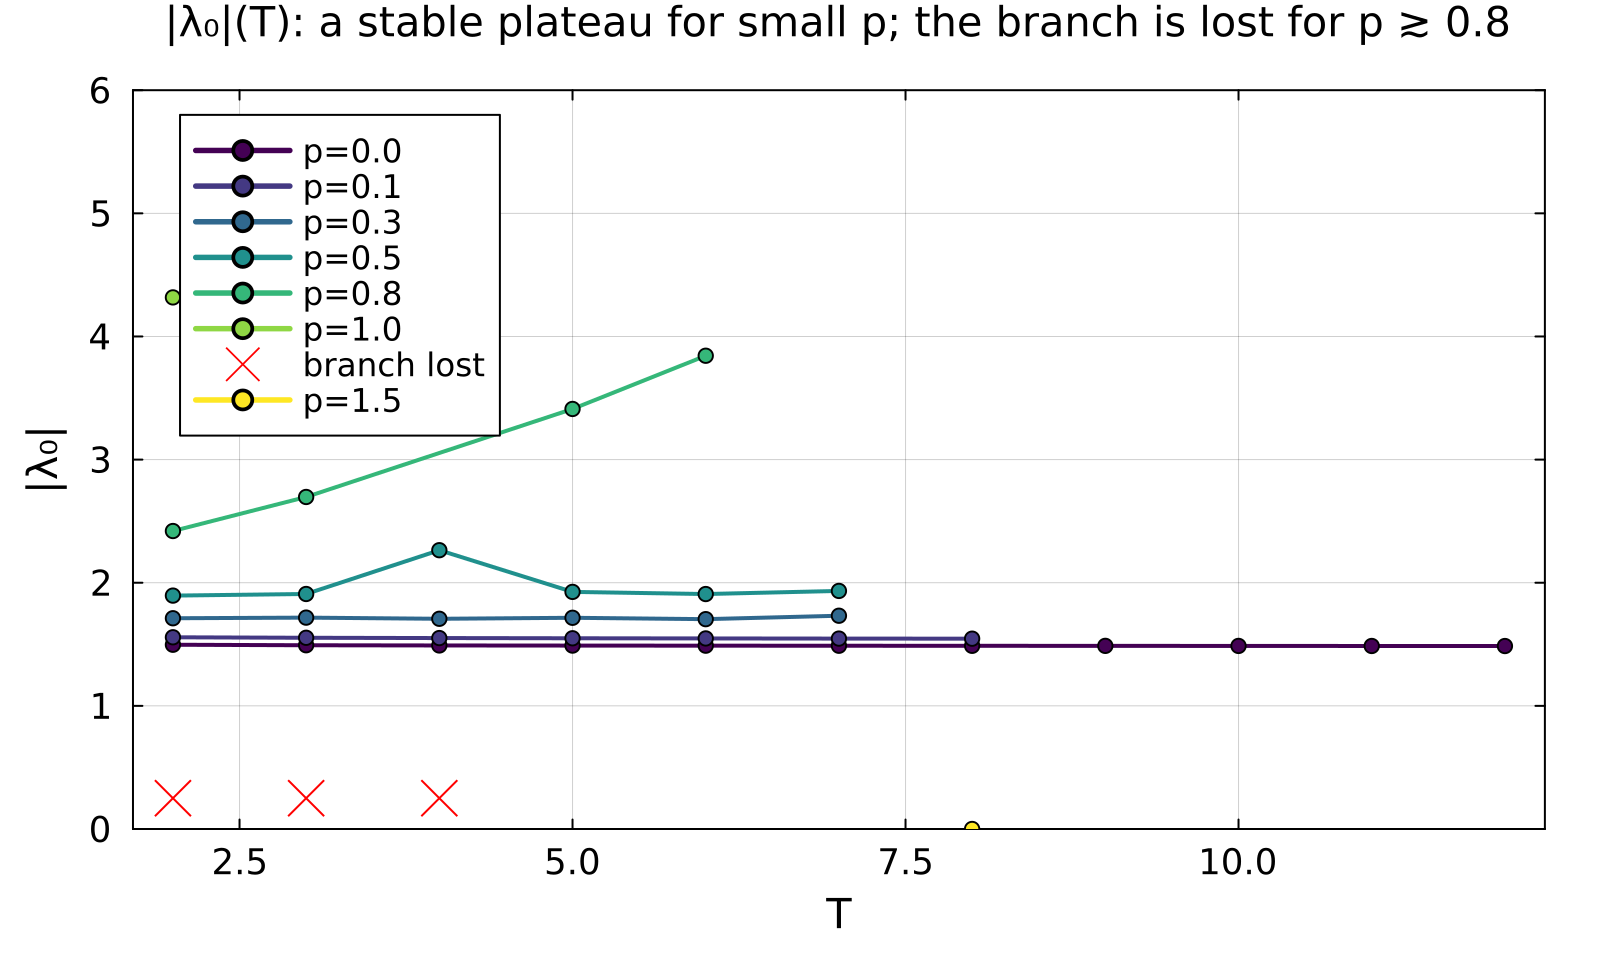

In [12]:
# Figure 3: the physical |λ0|(T) per p (corrected selector). Flat = the dual-unitarity plateau of a
# tracked physical branch. We plot only the trustworthy points (ok / nok1) and mark with a red × the
# first T where the branch is LOST (a suspect blow-up or a collapse-error) — the actual divergent
# |λ0| values (up to ~270) are off-scale and uninformative, so we clip to the physical range.
fig_lam = plot(xlabel="T", ylabel="|λ₀|", ylims=(0, 6), framestyle=:box, grid=true, legend=:topleft,
               title="|λ₀|(T): a stable plateau for small p; the branch is lost for p ≳ 0.8")
for (idx,(p,_)) in enumerate(psweep_files)
    haskey(warm, p) || continue
    rows = analyze_arm(p)
    good = [(r.T, r.mag) for r in rows if r.status in (:ok, :nok1)]
    isempty(good) || plot!(fig_lam, first.(good), last.(good); marker=:circle, ms=4, lw=2,
                           color=palette[idx], label="p=$p")
    lost = [r.T for r in rows if r.status in (:suspect, :error)]
    isempty(lost) || scatter!(fig_lam, [minimum(lost)], [0.25]; marker=:xcross, ms=9, color=:red,
                              label = idx==6 ? "branch lost" : "")
end
savefig(fig_lam, "../results/imgs/nb9_lambda0_vs_p.png")
fig_lam

For $p \lesssim 0.5$ the tower gap is a clean, monotone barrier. The latest cluster data extends
$p=0.5$ to $T=7$, where the gap plateaus near $0.95$ as it approaches its own wall; the stored
$p=0.5$ point was a selection artifact rather than bad physics, and the corrected selector recovers
it.

At $p=0.8$ the $k=4$ arm is erratic: $T=2$ captures no tower member, $T=4$ blows up, and $T=3$ and
$T=5$ recover. The physical branch is only intermittently trackable, which is the signature of an
arm that needs a $k=8$ rerun rather than a physics wall.

At $p=1.0$ and $1.5$ the leading spectrum has a near-exact top degeneracy, two eigenvalues equal to
close to machine precision, which the RTM solver cannot resolve. Most points hit the validity guard
and the rest are meaningless. That is a limit of the method at strong frustration, not an
infrastructure problem: $\chi$ is capped at 64 and the arms ran on 40 cores, about 80 GB, with no
memory failure.

The reach-against-$p$ panel is the compact statement. The reliable window of the method collapses as
the NNN frustration grows, reaching $T\approx12, 8, 7, 7$ at $p=0, 0.1, 0.3, 0.5$, and breaking down
beyond.

## Section 8. The August round: eigenvalues past the wall, and what post-processing can and cannot repair

The eigenvalue-only route was built for one reason. The entropy needs the eigenvectors, and those
stop being well defined at the wall; the eigenvalues are Rayleigh-quotient-like and do not. Running
in `:schur` mode skips the eigenvector work entirely, so an arm should reach much larger $T$ than the
full runs of section 6, which stalled at $T=7$ to $8$.

Six caches came back. Four eigenvalue-only arms at $p = 0, 0.1, 0.3, 0.5$; one full RDM run at
$p=0.1$; and one full RTM run at $p=0.3$ with entropy. None of the four eigsweep arms reached the
requested $T=20$, and two of them recorded errors on their last rungs, so the first thing to
establish is whether that is the method failing or the queue.

The cell below loads all six and reports, per arm, the largest $T$ that carried a usable result, the
cumulative compute behind it, and how the ladder ended.

In [13]:
# Load the August caches: reach, cost, and how each ladder ended.
august_files = [(:eigs, 0.0, "sweep_rtm_eigs_p0.0.jld2", "rtm_eigs_p0.0"),
                (:eigs, 0.1, "sweep_rtm_eigs_p0.1.jld2", "rtm_eigs_p0.1"),
                (:eigs, 0.3, "sweep_rtm_eigs_p0.3.jld2", "rtm_eigs_p0.3"),
                (:eigs, 0.5, "sweep_rtm_eigs_p0.5.jld2", "rtm_eigs_p0.5"),
                (:rdm,  0.1, "sweep_rdm_p0.1.jld2",      "rdm_p0.1"),
                (:full, 0.3, "sweep_rtm_p0.3.jld2",      "rtm_p0.3"),
                (:full, 0.5, "sweep_rtm_p0.5.jld2",      "rtm_p0.5")]

august = Dict{String,Any}()
for (kind, p, fname, label) in august_files
    path = joinpath("../results/data/cluster", fname)
    isfile(path) && (august[label] = (kind=kind, p=p, done=load(path, "done")))
end

@printf("%-16s %-6s %-8s %-10s %-9s %s\n", "arm", "kind", "reach", "cum hours", "n errors", "ended")
for (kind, p, fname, label) in august_files
    haskey(august, label) || continue
    entries = august[label].done
    Ts      = sort([k[2] for k in keys(entries)])
    ok_Ts   = [T for T in Ts if !haskey(entries[(label, T)], :error)]
    err_Ts  = [T for T in Ts if  haskey(entries[(label, T)], :error)]
    hours   = sum(entries[(label, T)].elapsed for T in ok_Ts) / 3600
    ending  = isempty(err_Ts) ? "stopped clean" : "errors from T=$(Int(minimum(err_Ts)))"
    @printf("%-16s %-6s T=%-6.0f %-10.1f %-9d %s\n",
            label, string(kind), maximum(ok_Ts), hours, length(err_Ts), ending)
end

arm              kind   reach    cum hours  n errors  ended
rtm_eigs_p0.0    eigs   T=20     28.8       0         stopped clean


rtm_eigs_p0.1    eigs   T=17     37.8       3         errors from T=18
rtm_eigs_p0.3    eigs   T=13     38.0       7         errors from T=14
rtm_eigs_p0.5    eigs   T=15     40.8       0         stopped clean
rdm_p0.1         rdm    T=12     36.8       0         stopped clean
rtm_p0.3         full   T=14     47.5       0         stopped clean
rtm_p0.5         full   T=6      5.4        0         stopped clean


Every arm stops between 37 and 48 hours of cumulative compute, and the SLURM scripts request
`--time=2-00:00:00`. That is the walltime, not a property of the transfer matrix. The two arms that
recorded errors were requeued and the fresh process could no longer build the time-evolution MPO;
the two that stop clean were killed outright. Neither failure mode says anything about the physics,
and both are recoverable by resubmitting from the checkpoint.

What the arms did deliver is the reach the eigenvalue route was supposed to buy: $T=20$ at $p=0$,
$T=17$ at $p=0.1$, $T=13$ at $p=0.3$, $T=15$ at $p=0.5$, against the $T=7$ to $8$ of the full runs.

The ladders are not clean, though. A few rungs carry a $|\lambda_0|$ far above the local baseline —
$3.62$ against $1.71$ at $p=0.3$, $T=12$, for instance. The next cell asks what those are.

In [14]:
# Outlier rungs: is the stored index wrong, or did the block not converge?
# Baseline is the arm's own median |θ0|, which a few outliers cannot move.
@printf("%-16s %-5s %-10s %-8s %-10s %s\n", "arm", "T", "|θ0|", "stored i0", "re-derived", "reason")
for (kind, p, fname, label) in august_files
    haskey(august, label) || continue
    entries = august[label].done
    Ts      = [T for T in sort([k[2] for k in keys(entries)]) if !haskey(entries[(label, T)], :error)]

    mags = Float64[]
    prev = nothing
    idxs = Int[]
    for T in Ts
        theta = collect(entries[(label, T)].theta)
        i0    = pick_phys_continuity(theta, prev)
        push!(mags, abs(theta[i0]))
        push!(idxs, i0)
        prev = theta[i0]
    end
    baseline = median(mags)

    for (n, T) in enumerate(Ts)
        abs(mags[n] - baseline) / baseline > 0.05 || continue
        @printf("%-16s %-5.0f %-10.5f %-8d %-10s %s\n", label, T, mags[n], entries[(label, T)].i0,
                idxs[n] == entries[(label, T)].i0 ? "unchanged" : "CHANGED", entries[(label, T)].reason)
    end
end
println("\n(outlier rungs only)")

arm              T     |θ0|       stored i0 re-derived reason
rtm_eigs_p0.3    4     1.94042    1        unchanged  stuck


rtm_eigs_p0.3    9     2.54184    1        unchanged  stuck
rtm_eigs_p0.3    12    3.61857    1        unchanged  stuck
rtm_eigs_p0.5    3     2.55276    1        unchanged  stuck
rtm_p0.3         4     2.23140    1        unchanged  converged
rtm_p0.3         12    2.90442    1        unchanged  stuck

(outlier rungs only)


Re-deriving the index changes nothing, anywhere. These runs already used the dominant-modulus
selector of section 5, so the fix that recovered the July $p=0.5$ arm has nothing left to do here.

So the outliers are not misselected. They are spurious Ritz values. Where the block power method
does not settle, the iterate carries a vector that is not an eigenvector, and its Rayleigh quotient
can land anywhere, including above the true leading modulus; dominant-modulus selection then returns
the artefact, correctly applying the right rule to a block that has no dominant member yet. Most of
these rungs are reported `stuck`, which is the expected signature, but not all: $p=0.3$, $T=4$ of the
full run is marked `converged` and is contaminated anyway. Convergence of the iteration is a weaker
guarantee than it sounds, which is the same lesson the RDM arm gives below.

That distinction matters for what can be done about it, which is the subject of the next cell.

### How the post-processing works, and where it applies

Everything in this notebook that repairs a cluster result is post-processing: it re-reads the stored
spectra and re-decides something, without recomputing any transfer matrix. Two such repairs now
exist, and they cover different failures.

The first is `pick_phys_continuity`, from section 5. It replaced a whole-block continuity rule that
tracked the nearest complex value between rungs. That rule fails because $\mathrm{Im}\,\lambda_0$
winds with $T$, so the nearest value is often a stationary partner rather than the physical branch,
and one slip cascades down the rest of the ladder. Dominant modulus is the robust discriminant, with
continuity used only to break a genuine sub-percent tie between a $\pm\pi$ pair.

The second is `pick_phys_robust`, added for this section. It restricts the candidates to those whose
modulus lies within 5% of the last accepted $|\lambda_0|$, and only then applies dominant modulus
among the survivors. The 5% is chosen from the data: $|\lambda_0|$ drifts by under half a percent per
rung on every converged arm, while the contamination is 13% and up, so the two do not overlap. If no
candidate survives the restriction the rung is reported unrecoverable rather than re-anchored, and
the reference keeps chaining from the last rung that was accepted.

The two repairs are not interchangeable. `pick_phys_continuity` fixes a wrong choice among candidates
that are all valid. `pick_phys_robust` fixes a block that contains an invalid candidate, and it works
only because the true $\lambda_0$ is usually still present further down the same $k=4$ block.

There is a third failure that post-processing cannot touch, and it is worth stating plainly, because
it sets the boundary of the method. The entropy is stored as an already-computed profile; the $L$ and
$R$ eigenvectors it came from are not in the cache. Re-selecting an index therefore cannot regenerate
an entropy. On a rung whose dome is contaminated, repairing $|\lambda_0|$ repairs the spectrum and
nothing else, and the rung has to be dropped from any dome figure.

In [15]:
# Re-derive every arm with the robust selector. Post-processing on the stored spectra.
repaired = Dict{String,Any}()
for (kind, p, fname, label) in august_files
    haskey(august, label) || continue
    entries = august[label].done
    ref     = nothing
    rows    = NamedTuple[]

    for T in sort([k[2] for k in keys(entries)])
        entry = entries[(label, T)]
        haskey(entry, :error) && continue
        theta = collect(entry.theta)
        i0, recovered = pick_phys_robust(theta, ref)

        push!(rows, (T=T, mag=abs(theta[i0]), gap=tower_gap(theta; i0=i0), peak=entry.peak,
                     stored=abs(entry.theta_phys), changed=(i0 != entry.i0), recovered=recovered))
        recovered && (ref = theta[i0])
    end
    repaired[label] = rows
end

for (kind, p, fname, label) in august_files
    haskey(repaired, label) || continue
    changed = [r for r in repaired[label] if r.changed]
    isempty(changed) && continue
    println("$label:")
    for r in changed
        @printf("   T=%-5.0f %.5f -> %.5f  (%.1f%% off)\n",
                r.T, r.stored, r.mag, 100*(r.stored - r.mag)/r.mag)
    end
end

rtm_eigs_p0.3:


   T=4     1.94042 -> 1.73135  (12.1% off)
   T=9     2.54184 -> 1.71046  (48.6% off)


   T=10    1.72068 -> 1.71254  (0.5% off)
   T=12    3.61857 -> 1.70454  (112.3% off)
rtm_eigs_p0.5:
   T=3     2.55276 -> 1.90865  (33.7% off)
rtm_p0.3:
   T=4     2.23140 -> 1.70720  (30.7% off)
   T=12    2.90442 -> 1.79183  (62.1% off)


The robust selector recovers every contaminated eigenvalue rung. At $p=0.3$ the $T=9$ and $T=12$
blow-ups to $2.54$ and $3.62$ come back to $1.710$ and $1.705$, in line with the $1.713$ baseline the
rest of that arm holds; $p=0.5$ recovers $T=3$ from $2.55$ to $1.91$. In every case the true
$\lambda_0$ was already sitting in the stored $k=4$ block.

The next cell separates what this does and does not fix, by putting the repaired spectrum next to the
stored dome peak on the two arms that carry entropy.

In [16]:
# On the arms with entropy: is the profile still a dome?
# A dome has one interior maximum. Once the eigenvectors go it develops several.
function count_humps(profile)
    return count(i -> profile[i] > profile[i-1] && profile[i] > profile[i+1], 2:length(profile)-1)
end

for label in ["rdm_p0.1", "rtm_p0.3", "rtm_p0.5"]
    haskey(repaired, label) || continue
    entries = august[label].done

    println("\n$label")
    @printf("  %-5s %-10s %-10s %-7s %s\n", "T", "|lambda0|", "peak", "humps", "")
    for r in repaired[label]
        humps = count_humps(real.(entries[(label, r.T)].s2_base))
        note  = r.changed ? "spectrum repaired" : (humps > 1 ? "not a dome" : "")
        @printf("  %-5.0f %-10.5f %-10.4f %-7d %s\n", r.T, r.mag, r.peak, humps, note)
    end
end


rdm_p0.1
  T     |lambda0|  peak       humps   
  2     1.55694    0.2023     1       


  3     1.55303    0.2387     1       
  4     1.55064    0.2643     1       
  5     1.54895    0.2836     1       
  6     1.54758    0.2990     1       
  7     1.54637    0.3118     1       
  8     1.54526    0.3227     1       
  9     1.54424    0.3321     1       
  10    1.54427    0.7157     2       not a dome
  11    1.54637    0.7184     2       not a dome
  12    1.54778    0.7228     2       not a dome

rtm_p0.3
  T     |lambda0|  peak       humps   
  2     1.71176    0.6943     1       
  3     1.71655    0.6942     1       
  4     1.70720    1.7548     1       spectrum repaired
  5     1.71531    0.7020     2       not a dome
  6     1.70407    0.7182     3       not a dome
  7     1.71201    0.7085     3       not a dome
  8     1.71353    0.7052     3       not a dome
  9     1.71046    0.7086     4       not a dome
  10    1.71378    0.7032     4       not a dome
  11    1.71382    0.7116     4       not a dome
  12    1.79183    1.6425     3       spectrum repaire

### Deciding whether a rung has hit the wall

The peak is not a reliable test. On the $p=0.3$ arm it sits near $0.70$ from $T=2$ all the way to
$T=14$, while the profile turns from a dome into an oscillation. Read the peak alone and that arm
looks healthy throughout.

Counting interior maxima catches the change: a dome has one, a broken profile has several. That is
better, but still not sufficient. At $p=0.3$, $T=4$ the profile has a single maximum and is
nevertheless useless, because it is one of the rungs whose spectrum the robust selector had to
repair; its peak is $1.75$ against the $0.70$ the arm reports everywhere else.

So a rung counts as a dome only when both conditions hold:

1. the profile has exactly one interior maximum, and
2. its spectrum needed no repair.

Every wall position quoted below uses that test. It matters: the hump count alone puts the $p=0.3$
wall one rung too late.

By this test the $p=0.3$ entropy is usable at $T=2$ and $T=3$ and nowhere else. From $T=5$ the
profile carries two maxima, then three, four, and six by $T=13$.

Repairing the spectrum does not rescue any of this, because the entropy was computed from
eigenvectors that are not in the file. The repaired rungs still contribute to the tower-gap and
central-charge reads; they are excluded from any dome figure, as is everything past the wall.

The $p=0.1$ RDM arm fails differently, and more gently, which is the subject of the last cell.

### The wall against frustration, and a check on the repair

The $p=0.5$ entropy arm was run on the desktop rather than the cluster. The wall was expected early,
so a short ladder was enough; it took five and a half hours. It completes the wall-against-$p$
picture, and since it repeats points the eigenvalue-only arm already covered, it also tests the
selector repair against data that repair never saw.

The cell below applies the two-part test of the previous section to every entropy arm, and puts the
two independent determinations of $|\lambda_0|$ side by side.

In [17]:
# Where each arm stops being a dome, and how the full runs compare with the eigenvalue-only ones.
# A rung counts as a dome only if it has one maximum AND its spectrum needed no repair: the
# contaminated rungs can still show a single hump while their entropy is meaningless.
function last_dome(rows, entries, label)
    reach = 0.0
    for r in rows
        r.changed && break
        count_humps(real.(entries[(label, r.T)].s2_base)) == 1 || break
        reach = r.T
    end
    return reach
end

# p=0 comes from the earlier sweep, which is the only entropy arm at that coupling
p0 = load("../results/data/cluster/sweep_rtm_p0.0.jld2", "done")
p0_reach = 0.0
for T in sort([k[2] for k in keys(p0)])
    e = p0[("rtm_p0.0", T)]
    haskey(e, :error) && continue
    count_humps(real.(e.s2_base)) == 1 || break
    global p0_reach = T
end

println("wall position from the dome shape:")
@printf("  p=%.1f   dome clean up to T=%.0f%s\n", 0.0, p0_reach, "   (ladder ends there)")
for (label, p) in [("rdm_p0.1", 0.1), ("rtm_p0.3", 0.3), ("rtm_p0.5", 0.5)]
    haskey(repaired, label) || continue
    @printf("  p=%.1f   dome clean up to T=%.0f\n", p,
            last_dome(repaired[label], august[label].done, label))
end

println("\nfull run against the eigenvalue-only arm at p=0.5:")
full = august["rtm_p0.5"].done
eigs = august["rtm_eigs_p0.5"].done
@printf("  %-5s %-12s %-12s %s\n", "T", "psweep", "eigsweep", "")
for T in sort([k[2] for k in keys(full)])
    haskey(eigs, ("rtm_eigs_p0.5", T)) || continue
    a = abs(full[("rtm_p0.5", T)].theta_phys)
    b = abs(eigs[("rtm_eigs_p0.5", T)].theta_phys)
    note = abs(a - b)/a > 0.01 ? "eigsweep rung was contaminated" : ""
    @printf("  %-5.0f %-12.5f %-12.5f %s\n", T, a, b, note)
end

wall position from the dome shape:
  p=0.0   dome clean up to T=12   (ladder ends there)
  p=0.1   dome clean up to T=9


  p=0.3   dome clean up to T=3
  p=0.5   dome clean up to T=2

full run against the eigenvalue-only arm at p=0.5:
  T     psweep       eigsweep     
  2     1.89540      1.89541      


  3     1.90860      2.55276      eigsweep rung was contaminated
  4     1.88595      1.88586      
  5     1.92549      1.92547      
  6     1.90826      1.90827      


The wall moves sharply earlier as frustration grows: $T=12$ at $p=0$, which is where that ladder
ends rather than where it breaks, then $T=9$, $T=3$ and $T=2$ at $p=0.1$, $0.3$ and $0.5$. Only
$p=0$ and $p=0.1$ give a dome over a useful range of $T$. At $p=0.3$ two rungs survive and at
$p=0.5$ one. That is a property of the model, not of the solver, and it fixes what the entropy route
can be asked for at each $p$.

The comparison underneath is the sharper check. The two arms agree to five decimals at every rung
they share, except $T=3$, where the eigenvalue-only run stored a contaminated value. The robust
selector had repaired that rung from the stored spectrum alone; the full run, computed independently
and using the eigenvectors, lands on the same number. The repair is not merely self-consistent, then:
it recovers what an independent calculation finds.

In [18]:
# The RDM control at p=0.1. A dome peaks mid-chain; once the eigenvectors go it grows two humps.
rdm_entries = august["rdm_p0.1"].done
@printf("%-5s %-10s %-10s %-12s %-12s %s\n", "T", "|λ0|", "peak", "min rigidity", "reason", "dome")
for T in sort([k[2] for k in keys(rdm_entries)])
    entry = rdm_entries[("rdm_p0.1", T)]
    haskey(entry, :error) && continue
    profile  = real.(entry.s2_base)
    position = argmax(profile) / length(profile)

    @printf("%-5.0f %-10.5f %-10.4f %-12.1e %-12s %s\n", T, abs(entry.theta_phys), entry.peak,
            minimum(entry.rigidity), entry.reason,
            0.35 < position < 0.65 ? "yes" : "no (peak off centre)")
end

T     |λ0|       peak       min rigidity reason       dome
2     1.55694    0.2023     6.7e-02      converged    yes


3     1.55303    0.2387     2.3e-02      converged    yes
4     1.55064    0.2643     7.2e-03      converged    yes
5     1.54895    0.2836     2.1e-03      converged    yes
6     1.54758    0.2990     6.2e-04      converged    yes
7     1.54637    0.3118     1.8e-04      converged    yes
8     1.54526    0.3227     5.3e-05      converged    yes
9     1.54424    0.3321     1.6e-05      converged    yes
10    1.54427    0.7157     4.6e-06      converged    no (peak off centre)
11    1.54637    0.7184     1.3e-06      converged    no (peak off centre)
12    1.54778    0.7228     3.9e-07      converged    no (peak off centre)


The RDM route does not move the wall. The dome is clean from $T=2$ to $T=9$, rising smoothly from
$0.202$ to $0.332$, and at $T=10$ it breaks: the peak jumps to $0.716$ and the maximum slides off
centre, the profile having grown two humps. That is the same $T$ at which the RTM route breaks, so
the wall is a property of the transfer matrix and not of the truncation algorithm. Together with the
bond-dimension scan of notebook 8 and the cutoff comparison of section 3, all the resolution knobs
are now closed.

Two details make the point sharper than the RTM data could. The solver reports `converged` at every
rung, including the broken ones, so the wall is not a failure of the iteration to settle; and the
smallest phase rigidity is $5\times10^{-6}$ at $T=10$, meaning every vector in the block is
degenerate at once and there is no better-conditioned partner to switch to. This is why no
post-processing rescues the RDM entropy past $T=9$, and why raising the iteration count would not
either.

What RDM is good for is the region below the wall. It held the physical branch at all eleven rungs,
where the July RTM run at the same $p=0.1$ slipped onto a partner at $T=3$ and never came back, so
its dome is the smooth one and it is the better source for a $p=0.1$ dome figure. That costs about
four times the RTM compute for the same eigenvalues, so it stays a control rather than the production
route, and there is no reason to extend it: further rungs would all land past the wall.

## Section 7. Verdict

All three $\varepsilon$ knobs are now closed: bond dimension in notebook 8, truncation algorithm and
cutoff in sections 1 to 3, and the RDM control past the wall in section 8. The entanglement barrier
is a property of the transfer matrix's closing gap, not of any resolution knob. Phase rigidity
collapses at the same rate under RTM, RDM or a tighter cutoff, and at $\chi=32$ or 64. RDM gives the
same eigenvalues for 4 to 11 times the cost and breaks at the same $T$, so production stays with RTM;
its one advantage is a cleaner dome below the wall at $p=0.1$, which is where it is used.

Three algorithmic findings came out of this and are now in `src/transverse_tools.jl`. The physical
$\lambda_0$ is selected by dominant modulus rather than complex continuity, which alone recovered
$p=0.5$ from the existing data; `block_transfer_eigs_adaptive` escalates $k\to6\to8$ until a tower
member appears, which is needed for $p\gtrsim0.8$ where the $k=4$ block is all partners; and
`pick_phys_robust` restricts the candidates to a 5% window around the last accepted $|\lambda_0|$
before applying dominant modulus, which is what recovers a rung whose block never converged.

The $p$-sweep shows the temporal barrier surviving frustration cleanly up to $p=0.5$. The
eigenvalue-only arms of section 8 carry the spectrum to $T=20, 17, 13, 15$ at $p=0, 0.1, 0.3, 0.5$,
against the $T=7$ to $8$ of the full runs, which is what that route was built for. At $p=0.8$ the
$k=4$ data is erratic and needs a $k=8$ rerun to be measurable. At $p\ge1.0$ the method collapses
against a near-exact top degeneracy, a genuine limit at strong frustration rather than a memory
problem.

What remains: none of the four eigenvalue arms reached $T=20$, all four having run out of walltime,
so they resume from their checkpoints. The $p=0.5$ entropy dome has no source yet — the eigsweeps
carry no entropy and the July $p=0.5$ full run is unusable — so `psweep 0.5` is the one genuinely new
job. The RDM arm should not be extended: it has answered its question and further rungs would all
land past the wall. For $p\ge1.0$ the honest thesis figure is the reach-against-$p$ panel of
section 6, not a central charge at $p=1$.